In [8]:
!pip install tensorboard

SyntaxError: invalid syntax (1728078699.py, line 1)

In [18]:
import io, os, re
# check common locations
for path in ['runs/', os.path.expanduser('~/scratch/runs/'), os.path.expanduser('~/weaver-core-dev/runs/')]:
    if os.path.exists(path):
        print(path, os.listdir(path))

runs/ ['Sep20_16-04-09_gpu2708.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon', 'Sep20_18-07-10_gpu2708.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon', 'Sep20_18-56-30_gpu2708.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon']


In [2]:
import tensorboard
from tensorboard.backend.event_processing import event_accumulator
logdir='runs/Sep20_18-56-30_gpu2708.oscar.ccv.brown.edu_ak8_MD_inclv10_scouting_Upsilon'
ea = event_accumulator.EventAccumulator(logdir, size_guidance={'images': 0, 'scalars': 0})
ea.Reload()
print(ea.Tags())

{'images': ['MassReg/target_res_mass_factor/all/diagnostics (eval)', 'MassRegVsPt/target_res_mass_factor/all/diagnostics (eval)'], 'audio': [], 'histograms': [], 'scalars': ['Loss/train', 'LossReg/train', 'Acc/train', 'Loss/train (epoch)', 'LossReg/train (epoch)', 'LossTot/train (epoch)', 'Acc/train (epoch)', 'Loss/eval (epoch)', 'LossReg/eval (epoch)', 'LossTot/eval (epoch)', 'Acc/eval (epoch)', 'MassReg/target_res_mass_factor/all/resp_median (eval)', 'MassReg/target_res_mass_factor/all/resp_resolution (eval)', 'MassReg/target_res_mass_factor/all/resp_mean (eval)', 'MassRegVsPt/target_res_mass_factor/all/pt25-50/resp_median (eval)', 'MassRegVsPt/target_res_mass_factor/all/pt25-50/resp_resolution (eval)', 'MassRegVsPt/target_res_mass_factor/all/pt50-100/resp_median (eval)', 'MassRegVsPt/target_res_mass_factor/all/pt50-100/resp_resolution (eval)', 'MassRegVsPt/target_res_mass_factor/all/pt100-150/resp_median (eval)', 'MassRegVsPt/target_res_mass_factor/all/pt100-150/resp_resolution (eva

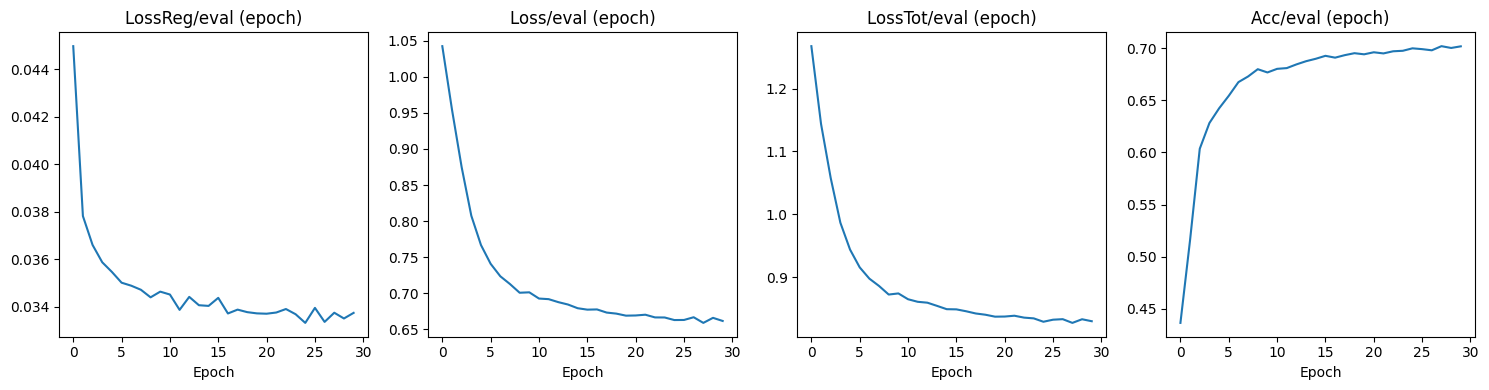

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, tag in zip(axes, ['LossReg/eval (epoch)', 'Loss/eval (epoch)', 'LossTot/eval (epoch)', 'Acc/eval (epoch)'] ):
    try:
        scalars = ea.Scalars(tag)
        steps = [s.step for s in scalars]
        values = [s.value for s in scalars]
        ax.plot(steps, values)
        ax.set_title(tag)
        ax.set_xlabel('Epoch')
    except:
        print(f'{tag} not found')

plt.tight_layout()
plt.savefig('training_curves.png')
plt.show()

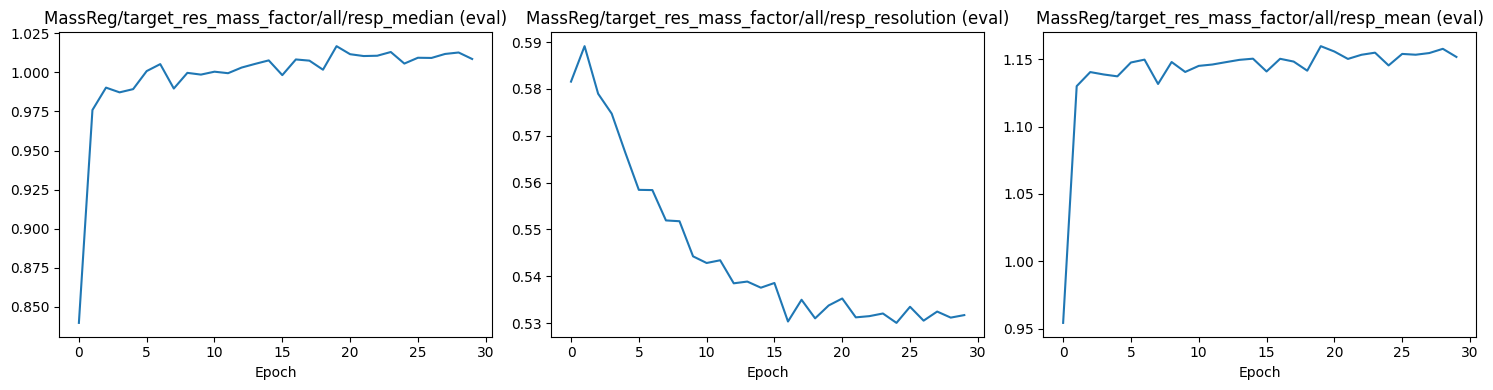

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, tag in zip(axes, ['MassReg/target_res_mass_factor/all/resp_median (eval)', 'MassReg/target_res_mass_factor/all/resp_resolution (eval)', 'MassReg/target_res_mass_factor/all/resp_mean (eval)'] ):
    try:
        scalars = ea.Scalars(tag)
        steps = [s.step for s in scalars]
        values = [s.value for s in scalars]
        ax.plot(steps, values)
        ax.set_title(tag)
        ax.set_xlabel('Epoch')
    except:
        print(f'{tag} not found')

plt.tight_layout()
# plt.savefig('training_curves.png')
plt.show()

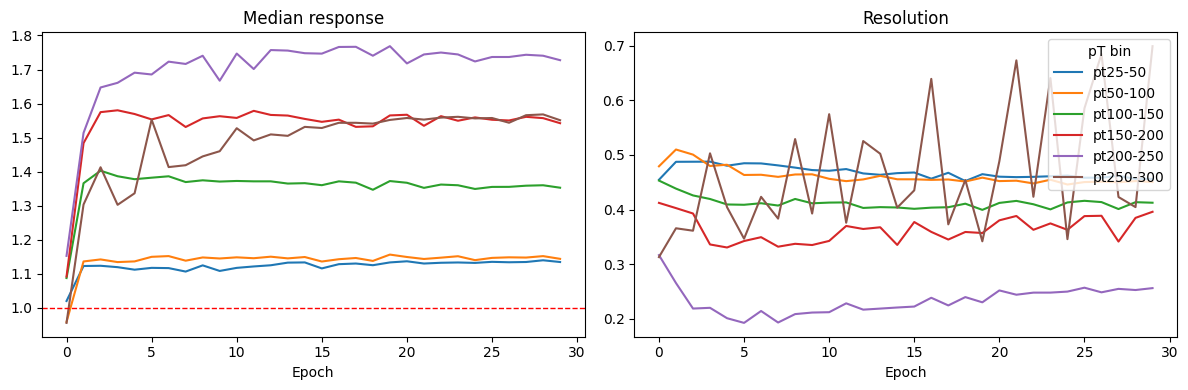

In [16]:
pt_bins = ['pt25-50', 'pt50-100', 'pt100-150', 'pt150-200', 'pt200-250', 'pt250-300']
base = 'MassRegVsPt/target_res_mass_factor/all'

fig, (ax_m, ax_r) = plt.subplots(1, 2, figsize=(12, 4))
for b in pt_bins:
    for ax, m in ((ax_m, 'resp_median'), (ax_r, 'resp_resolution')):
        sc = ea.Scalars(f'{base}/{b}/{m} (eval)')
        ax.plot([s.step for s in sc], [s.value for s in sc], label=b)
ax_m.axhline(1, color='r', ls='--', lw=1)
ax_m.set_title('Median response'); ax_r.set_title('Resolution')
for ax in (ax_m, ax_r):
    ax.set_xlabel('Epoch')
ax_r.legend(title='pT bin')
plt.tight_layout(); plt.show()

In [19]:
from PIL import Image
outdir = 'exported_plots'
os.makedirs(outdir, exist_ok=True)


for tag in ea.Tags()['images']:
    safe = re.sub(r'[^A-Za-z0-9_.-]+', '_', tag)
    for ev in ea.Images(tag):
        img = Image.open(io.BytesIO(ev.encoded_image_string))
        img.save(os.path.join(outdir, '%s_epoch%03d.png' % (safe, ev.step)))
